In [10]:
import ee
import geemap
import os

In [11]:
Map1 = geemap.Map()
Map1

Map(center=[0, 0], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', transp…

Creating Two Engine Layers

Two raster datasets from Google Earth Engine were used in this Project. The first dataset was a soil dataset (SOLUS), representing underlying soil properties. The second dataset was MODIS NDVI (MOD13A2), which measures vegetation health. These two layers were selected because soil conditions influence vegetation growth, making NDVI a useful indicator for understanding environmental patterns related to soil.


In [ ]:
Layer 1 (Image)
# Load SOLUS SOC raster
soc = ee.Image("USDA/SOLUS100/V0/soc")
soc_surface = soc.select("r_0_cm_p")

# Prepare polygon dataset
work_dir = os.path.expanduser("~/gee_data")
os.makedirs(work_dir, exist_ok=True)

in_shp = os.path.join(work_dir, "us_states.shp")

if not os.path.exists(in_shp):
    data_url = "https://github.com/giswqs/data/raw/main/us/us_states.zip"
    geemap.download_from_url(data_url, out_dir=work_dir)

# Convert shapefile to EE FeatureCollection
states_fc = geemap.shp_to_ee(in_shp)

# Calculate mean zonal statistics
zonal_stats = soc_surface.reduceRegions(
    collection=states_fc,
    reducer=ee.Reducer.mean(),
    scale=100
)

# Convert to GeoDataFrame
gdf = geemap.ee_to_gdf(zonal_stats)

# Show results
print(gdf.head())
print(gdf.info())

                                            geometry  id         mean  \
0  POLYGON ((-87.3593 35.00118, -85.60668 34.9847...  AL   883.283115   
1  MULTIPOLYGON (((-131.60202 55.11798, -131.5691...  AK          NaN   
2  POLYGON ((-109.0425 37.00026, -109.04798 31.33...  AZ   549.283405   
3  POLYGON ((-94.47384 36.50186, -90.15254 36.496...  AR  1592.855699   
4  POLYGON ((-123.23326 42.00619, -122.37885 42.0...  CA  2314.347927   

         name  
0     Alabama  
1      Alaska  
2     Arizona  
3    Arkansas  
4  California  
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   geometry  50 non-null     geometry
 1   id        50 non-null     object  
 2   mean      48 non-null     float64 
 3   name      50 non-null     object  
dtypes: float64(1), geometry(1), object(2)
memory usage: 1.7+ KB
None


In [108]:

# Set visualization parameters
soc_vis = {
    "min": 0,
    "max": 2000,
    "palette": ["fff7bc", "fee391", "fec44f", "fe9929", "ec7014", "cc4c02", "993404"],
}


Map1.addLayer(soc_surface, soc_vis, "Surface Soil Organic Carbon", True, 1)
Map1

Map(bottom=2175.33447265625, center=[15.029685756555674, -95.31738281250001], controls=(WidgetControl(options=…

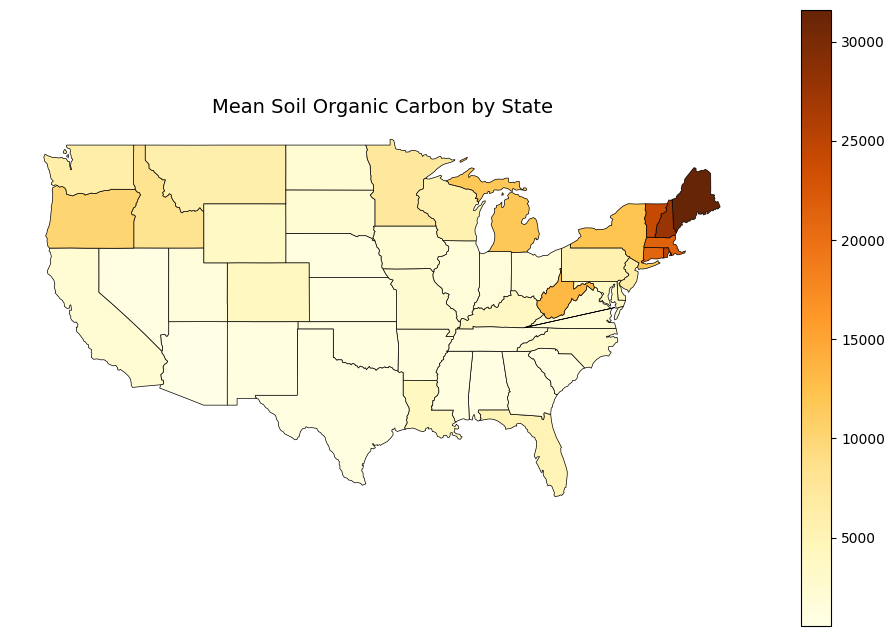

In [60]:
import matplotlib.pyplot as plt

# Remove states with missing soil values
gdf_clean = gdf.dropna(subset=["mean"])

# Plot mean soil organic carbon by state
fig, ax = plt.subplots(figsize=(12, 8))
gdf_clean.plot(
    column="mean",
    cmap="YlOrBr",
    linewidth=0.5,
    edgecolor="black",
    legend=True,
    ax=ax
)

ax.set_title("Mean Soil Organic Carbon by State", fontsize=14)
ax.axis("off")
plt.show()

Loading gdf_full into DUCKDB

In [25]:
import duckdb

In [33]:
!pip install duckdb spatial

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for spatial: filename=spatial-0.2.0-py3-none-any.whl size=8561 sha256=9fff70731fe5817653bb44444eb328056a80e0a812f6d68aceac94126dd46c0b
  Stored in directory: c:\users\oj640\appdata\local\pip\cache\wheels\a2\97\80\ec5f142a6927e83c8ab4c34acfda406786546ce45bb456dc91
Successfully built spatial


In [34]:
duck_con.execute("INSTALL spatial;")
duck_con.execute("LOAD spatial;")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [109]:
gdf_duck = gdf_clean.copy()
gdf_duck["geometry"] = gdf_duck.geometry.to_wkt()

duck_con.register("soil_gdf", gdf_duck)

In [36]:
duck_con.execute("""
    CREATE OR REPLACE TABLE soil_by_state AS
    SELECT
        mean,
        name,
        id,
        ST_GeomFromText(geometry) AS geometry
    FROM soil_gdf
""")

QUERIES IN DUCKDB

In [38]:
duck_con.execute("""
    SELECT name, mean
    FROM soil_by_state
    ORDER BY mean DESC
    LIMIT 10
""").df()

,name,mean
0,Maine,31590.102836
1,New Hampshire,27696.803572
2,Rhode Island,25162.643765
3,Vermont,24279.526939
4,Massachusetts,21632.612770
5,Connecticut,21165.446625
6,West Virginia,13251.723183
7,New York,12143.458406
8,Michigan,11702.516453
9,Oregon,10030.146527


In [49]:
#States with high soil organic carbon:
high = duck_con.execute("""
SELECT name, mean
FROM soil_by_state
WHERE mean > 1500
ORDER BY mean DESC
""").df()
high

,name,mean
0,Maine,31590.102836
1,New Hampshire,27696.803572
2,Rhode Island,25162.643765
3,Vermont,24279.526939
4,Massachusetts,21632.612770
5,Connecticut,21165.446625
6,West Virginia,13251.723183
7,New York,12143.458406
8,Michigan,11702.516453
9,Oregon,10030.146527


In [48]:
#States with modetate soil organic carbon:
moderate = duck_con.execute("""
SELECT name, id, mean
FROM soil_by_state
WHERE mean BETWEEN 800 AND 1500
ORDER BY mean DESC
""").df()

moderate

,name,id,mean
0,Tennessee,TN,1340.696641
1,Georgia,GA,1331.443034
2,Kansas,KS,1230.893016
3,Nebraska,NE,1103.694610
4,Texas,TX,1075.234593
5,South Carolina,SC,1056.279518
6,New Mexico,NM,1021.832725
7,Mississippi,MS,950.297457
8,Oklahoma,OK,926.383068
9,Alabama,AL,883.283115


In [47]:
low = duck_con.execute("""
SELECT name, id, mean
FROM soil_by_state
WHERE mean < 1000
ORDER BY mean ASC
""").df()

low


,name,id,mean
0,Arizona,AZ,549.283405
1,Nevada,NV,804.239839
2,Alabama,AL,883.283115
3,Oklahoma,OK,926.383068
4,Mississippi,MS,950.297457


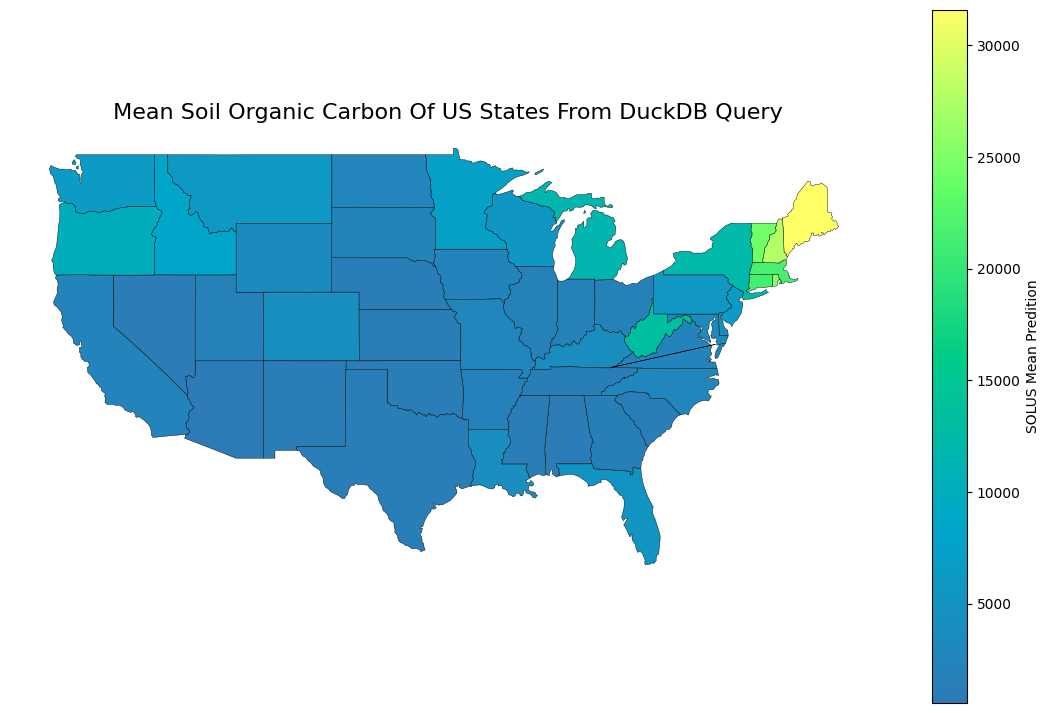

In [62]:
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.pyplot as plt

custom_cmap = LinearSegmentedColormap.from_list(
    "custom_green_blue",
    [
        "#2c7bb6",  # blue
        "#00a6ca",  # cyan
        "#00cc88",  # green
        "#66ff66",  # bright green
        "#ffff66"   # yellow highlight
    ]
)

fig, ax = plt.subplots(figsize=(14, 9))

gdf_clean.plot(
    column="mean",
    cmap=custom_cmap,
    linewidth=0.3,
    edgecolor="black",
    legend=True,
    legend_kwds={"label": "SOLUS Mean Predition"},
    ax=ax
)

ax.set_title(" Mean Soil Organic Carbon Of US States From DuckDB Query", fontsize=16)
ax.axis("off")

plt.show()

In [ ]:
Layer 2 (Image Collection)
work_dir = os.getcwd()

dataset = ee.ImageCollection("MODIS/061/MOD13A2") \
    .filter(ee.Filter.date("2018-01-01", "2018-12-31"))

ndviBand = dataset.select("NDVI").mean().multiply(0.0001).rename("ndvi")

states = ee.FeatureCollection("TIGER/2018/States")

state_mean_ndvi = ndviBand.reduceRegions(
    collection=states,
    reducer=ee.Reducer.mean(),
    scale=1000
)

print(state_mean_ndvi.limit(5).getInfo())

out_geojson = os.path.join(work_dir, "states_modis_ndvi.geojson")
geemap.ee_export_vector(state_mean_ndvi, filename=out_geojson)

{'type': 'FeatureCollection', 'columns': {'ALAND': 'Long', 'AWATER': 'Long', 'DIVISION': 'String', 'FUNCSTAT': 'String', 'GEOID': 'String', 'INTPTLAT': 'String', 'INTPTLON': 'String', 'LSAD': 'String', 'MTFCC': 'String', 'NAME': 'String', 'REGION': 'String', 'STATEFP': 'String', 'STATENS': 'String', 'STUSPS': 'String', 'mean': 'Float<-3.2768, 3.2767>', 'system:index': 'String'}, 'features': [{'type': 'Feature', 'geometry': {'type': 'MultiPolygon', 'coordinates': [[[[-64.95671144437794, 17.67898888553738], [-64.95648699623378, 17.67234612021062], [-64.95558929568621, 17.66875547663511], [-64.95505071273082, 17.666601071539457], [-64.9531656340593, 17.66103552970995], [-64.94970963923265, 17.653270716750747], [-64.94356057947924, 17.64411456610741], [-64.9351673822318, 17.635182780761177], [-64.92583171388065, 17.629033734003933], [-64.91591245655609, 17.625218650608453], [-64.9080130474639, 17.623961935316306], [-64.90038285001347, 17.623468206630278], [-64.89252833704256, 17.6242312865

In [72]:
import geopandas as gpd

# Load first 10 rows (test)
gdf = gpd.read_file('states_modis_ndvi.geojson', rows=10)

gdf.head()

,id,mean,STATENS,GEOID,AWATER,LSAD,STUSPS,STATEFP,FUNCSTAT,INTPTLAT,DIVISION,REGION,NAME,INTPTLON,MTFCC,ALAND,geometry
0,00000000000000000022,0.597024,01802710,78,1550236201,00,VI,78,A,+18.3267480,0,9,United States Virgin Islands,-064.9712508,G4000,348021896,"MULTIPOLYGON (((-64.95671 17.67899, -64.95649 ..."
1,00000000000000000023,0.573446,01779809,69,4644252461,00,MP,69,A,+14.9367835,0,9,Commonwealth of the Northern Mariana Islands,+145.6010210,G4000,472292529,"MULTIPOLYGON (((146.00197 16.02877, 146.00224 ..."
2,00000000000000000024,0.619754,01802705,66,934337453,00,GU,66,A,+13.4382886,0,9,Guam,+144.7729493,G4000,543555840,"POLYGON ((144.56342 13.44807, 144.56355 13.445..."
3,00000000000000000029,0.568832,01802701,60,1307243754,00,AS,60,A,-14.2671590,0,9,American Samoa,-170.6682674,G4000,197759063,GEOMETRYCOLLECTION (LINESTRING (-170.8231 -14....
4,00000000000000000031,0.694734,01779808,72,4922382562,00,PR,72,A,+18.2176480,0,9,Puerto Rico,-066.4107992,G4000,8868896030,"MULTIPOLYGON (((-67.54302 18.38613, -67.54244 ..."


<Axes: >

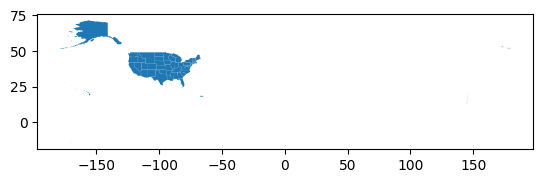

In [73]:


# Load your MODIS GeoJSON
gdf_full = gpd.read_file('states_modis_ndvi.geojson')

# Plot it (same simple style)
gdf_full.plot()

In [74]:
# Keep only mainland US
gdf_main = gdf_full[~gdf_full['NAME'].isin(['Alaska', 'Hawaii', 'Puerto Rico'])]

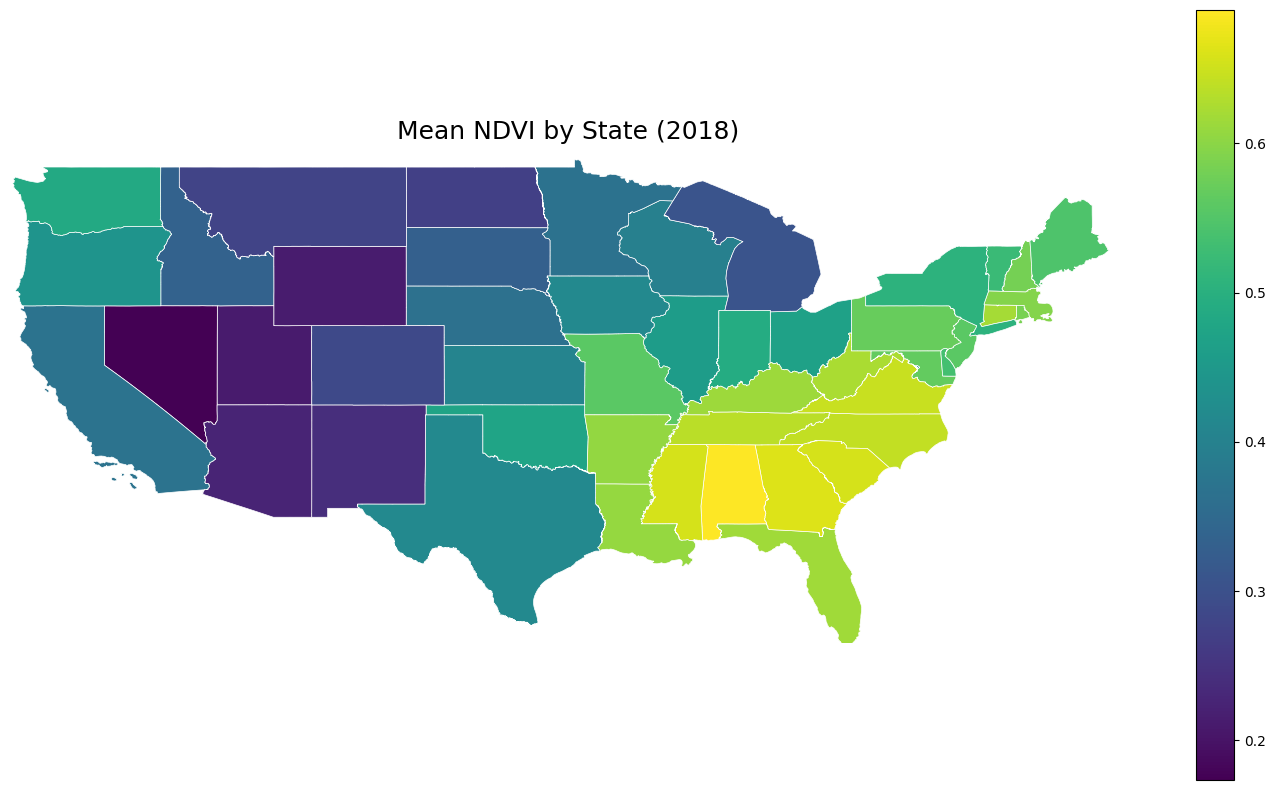

In [76]:
fig, ax = plt.subplots(figsize=(18, 10))

gdf_main.plot(
    ax=ax,
    column='mean',
    cmap='viridis',
    legend=True,
    edgecolor='white',
    linewidth=0.5
)

ax.set_xlim(-125, -66)
ax.set_ylim(25, 50)

plt.title("Mean NDVI by State (2018)", fontsize=18)
ax.set_axis_off()

plt.show()

Loading gdf_full into DUCKDB

In [ ]:

# Create DuckDB connection (in-memory)
con = duckdb.connect()

# Load spatial extension
con.execute("INSTALL spatial;")
con.execute("LOAD spatial;")

In [82]:
gdf_full["geom_wkt"] = gdf_full.geometry.to_wkt()

In [83]:
gdf_duck = gdf_full.drop(columns="geometry")

In [95]:
con.register("ndvi_states", gdf_duck)

In [96]:
con.sql("""
SELECT NAME, mean
FROM ndvi_states
ORDER BY mean DESC
LIMIT 10
""").df()

,NAME,mean
0,Puerto Rico,0.694734
1,Alabama,0.689383
2,Georgia,0.662686
3,South Carolina,0.656975
4,Mississippi,0.656210
5,Virginia,0.645578
6,North Carolina,0.642880
7,Tennessee,0.636924
8,West Virginia,0.624252
9,Connecticut,0.620093


In [97]:
con.sql("""
SELECT 
    AVG(mean) AS avg_ndvi,
    MIN(mean) AS min_ndvi,
    MAX(mean) AS max_ndvi
FROM ndvi_states
""").df()

,avg_ndvi,min_ndvi,max_ndvi
0,0.482952,0.173418,0.694734


In [98]:
con.sql("""
SELECT 
    NAME,
    mean,
    CASE 
        WHEN mean >= 0.6 THEN 'High'
        WHEN mean >= 0.4 THEN 'Moderate'
        ELSE 'Low'
    END AS ndvi_class
FROM ndvi_states
ORDER BY mean DESC
""").df()

,NAME,mean,ndvi_class
0,Puerto Rico,0.694734,High
1,Alabama,0.689383,High
2,Georgia,0.662686,High
3,South Carolina,0.656975,High
4,Mississippi,0.656210,High
5,Virginia,0.645578,High
6,North Carolina,0.642880,High
7,Tennessee,0.636924,High
8,West Virginia,0.624252,High
9,Connecticut,0.620093,High


In [101]:
arrow_table = con.sql("""
SELECT 
    NAME,
    mean,
    CASE 
        WHEN mean >= 0.6 THEN 'High'
        WHEN mean >= 0.4 THEN 'Moderate'
        ELSE 'Low'
    END AS ndvi_class,
    ST_GeomFromText(geom_wkt) AS geom
FROM ndvi_states
""").arrow()

In [103]:
import geopandas as gpd

arrow_table = con.sql("""
SELECT 
    NAME,
    mean,
    CASE 
        WHEN mean >= 0.6 THEN 'High'
        WHEN mean >= 0.4 THEN 'Moderate'
        ELSE 'Low'
    END AS ndvi_class,
    ST_AsWKB(ST_GeomFromText(geom_wkt)) AS geom
FROM ndvi_states
""").arrow()

table = arrow_table.read_all()

gdf_plot = gpd.GeoDataFrame(
    table.to_pandas(),
    geometry=gpd.GeoSeries.from_wkb(table["geom"].to_pylist()),
    crs="EPSG:4326"
)

gdf_plot.head()

,NAME,mean,ndvi_class,geom,geometry
0,United States Virgin Islands,0.597024,Moderate,b'\x01\x06\x00\x00\x00\x02\x00\x00\x00\x01\x03...,"MULTIPOLYGON (((-64.95671 17.67899, -64.95649 ..."
1,Commonwealth of the Northern Mariana Islands,0.573446,Moderate,b'\x01\x06\x00\x00\x00\x0c\x00\x00\x00\x01\x03...,"MULTIPOLYGON (((146.00197 16.02876, 146.00224 ..."
2,Guam,0.619754,High,b'\x01\x03\x00\x00\x00\x01\x00\x00\x00`\x02\x0...,"POLYGON ((144.56342 13.44807, 144.56355 13.445..."
3,American Samoa,0.568832,Moderate,b'\x01\x07\x00\x00\x00\x05\x00\x00\x00\x01\x02...,GEOMETRYCOLLECTION (LINESTRING (-170.8231 -14....
4,Puerto Rico,0.694734,High,b'\x01\x06\x00\x00\x00\x03\x00\x00\x00\x01\x03...,"MULTIPOLYGON (((-67.54302 18.38612, -67.54244 ..."


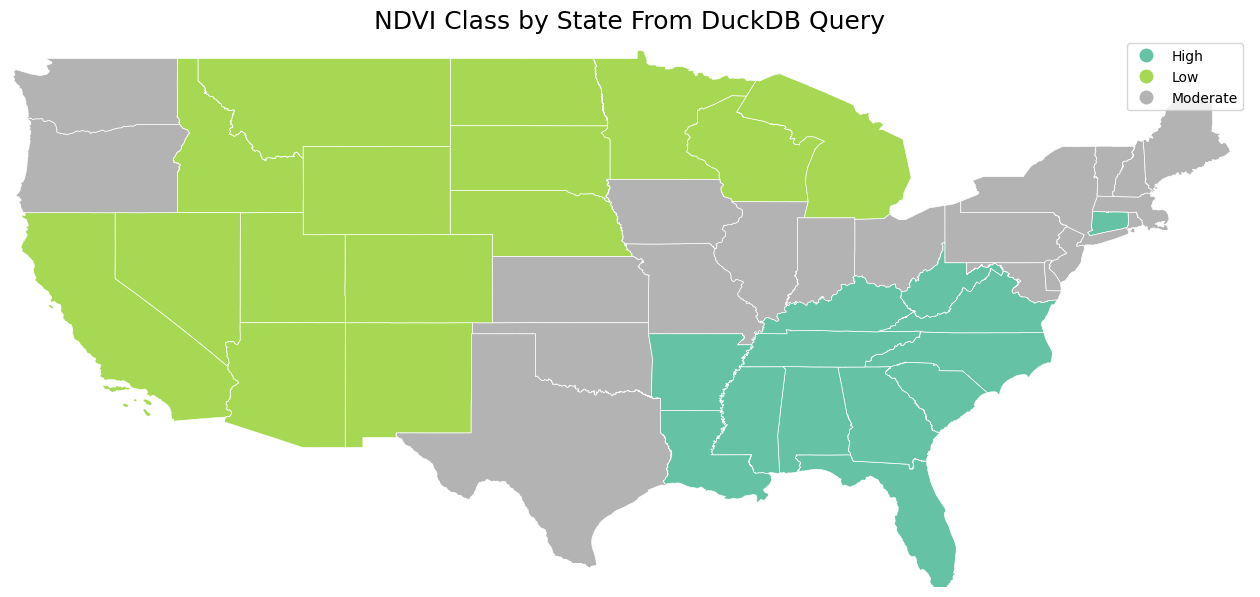

In [105]:
import matplotlib.pyplot as plt

gdf_plot = gdf_plot[~gdf_plot["NAME"].isin(["Alaska", "Hawaii", "Puerto Rico"])]

fig, ax = plt.subplots(figsize=(16, 10))

gdf_plot.plot(
    column="ndvi_class",
    categorical=True,
    legend=True,
    cmap="Set2",
    edgecolor="white",
    linewidth=0.5,
    ax=ax
)

ax.set_xlim(-125, -66)
ax.set_ylim(25, 50)
ax.set_title("NDVI Class by State From DuckDB Query", fontsize=18)
ax.set_axis_off()

plt.show()

The Process
1. The Project began by loading two raster datasets from Google Earth Engine:
SOLUS Soil Dataset → Soil Organic Carbon (r_0_cm_p)
MODIS NDVI Dataset → Vegetation index

2. I then Extracted relevant bands/images
Soil → single band (r_0_cm_p)
NDVI → averaged composite for the 2018

3. A US state shapefile was used as the polygon layer (Vector data) for zonal statistics.

4. Mean values of both datasets were calculated for each state(Extract values using zonal statistics)

5. Each result was exported as shapefile

6.  I then Loaded shapefiles into Geodataframe/GeoPandas

7. Open DuckDB connection

8. Loaded GeoDataFrame into DuckDB

9.  I performed Queries using SQL in DuckDB

10.  I created  maps (visualization) from the DUCKDB Query


Next work
Future work will explore the statistical relationship between NDVI and soil organic carbon to determine whether vegetation productivity is a strong predictor of soil carbon distribution. This work will be conducted at finer spatial scales, such as counties or grid cells, to better capture local variability in soil and vegetation conditions.